In [2]:
# Khai báo thư viện
import numpy as np
import cv2
from matplotlib import pyplot as plt

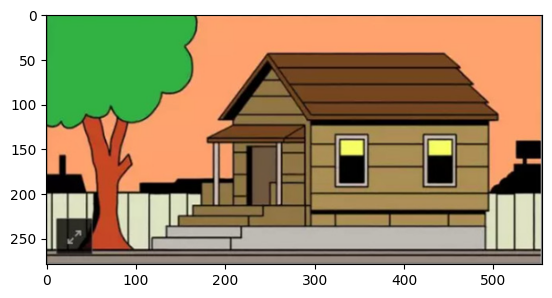

In [3]:
img = cv2.imread("image.png")
plt.imshow(img[:, :, ::-1])

# Harris Corner

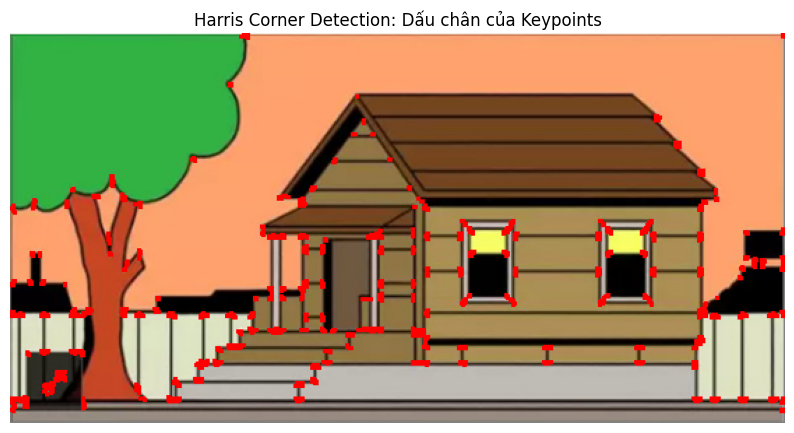

In [4]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Giữ lại bản màu
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Ép kiểu dữ liệu
gray = np.float32(gray)

# Harris Corner
# blockSize: Kích thước vùng lân cận để xét (2x2)
# ksize: Khẩu độ của bộ lọc Sobel (3)
# k: Tham số thực nghiệm của Harris (thường nằm ở mốc 0.04)
dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

# Giãn nở kết quả (Tùy chọn)
# Bước này giúp các điểm góc to và rõ ràng hơn để chúng ta dễ nhìn bằng mắt thường.
dst = cv2.dilate(dst, None)

# Lọc ngưỡng (Thresholding)
# Chỉ giữ lại những điểm có độ "góc cạnh" vượt qua 1% giá trị max.
# Những điểm thỏa mãn sẽ được nhuộm đỏ chót!
img_rgb[dst > 0.01 * dst.max()] = [255, 0, 0]

plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title("Harris Corner Detection: Dấu chân của Keypoints")
plt.axis("off")
plt.show()

# Difference of Gaussians

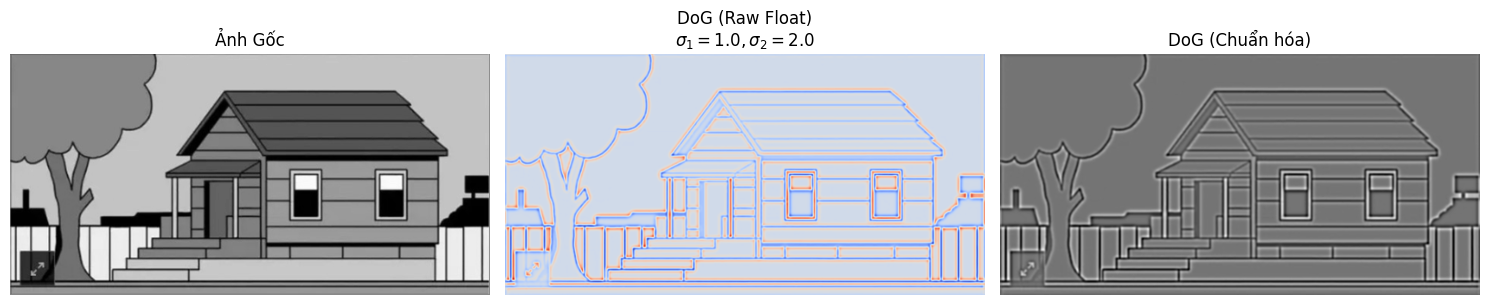

In [5]:
# Tạo hai ảnh mờ (Gaussian Blur) với sigma khác nhau
# Kích thước kernel (0, 0) nghĩa là OpenCV sẽ tự động tính toán dựa trên giá trị sigma.
sigma1 = 1.0
sigma2 = 2.0
blur1 = cv2.GaussianBlur(gray, (0, 0), sigmaX=sigma1)  # Mờ ít
blur2 = cv2.GaussianBlur(gray, (0, 0), sigmaX=sigma2)  # Mờ nhiều

# DoG: Trừ hai ảnh mờ cho nhau
dog_result = blur1 - blur2

# Chuẩn hóa lại kết quả để hiển thị (đưa về dải 0-255)
# Vì kết quả DoG có thể chứa giá trị âm, ta cần dời trục và scale lại.
dog_normalized = cv2.normalize(
    dog_result, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Ảnh Gốc")
plt.axis("off")

plt.subplot(1, 3, 2)
# Hiển thị kết quả DoG dạng heatmap để thấy rõ các giá trị âm/dương
plt.imshow(dog_result, cmap="coolwarm")
plt.title(f"DoG (Raw Float)\n$\sigma_1={sigma1}, \sigma_2={sigma2}$")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(dog_normalized, cmap="gray")
plt.title("DoG (Chuẩn hóa)")
plt.axis("off")

plt.tight_layout()
plt.show()

# Automatic Scale Selection

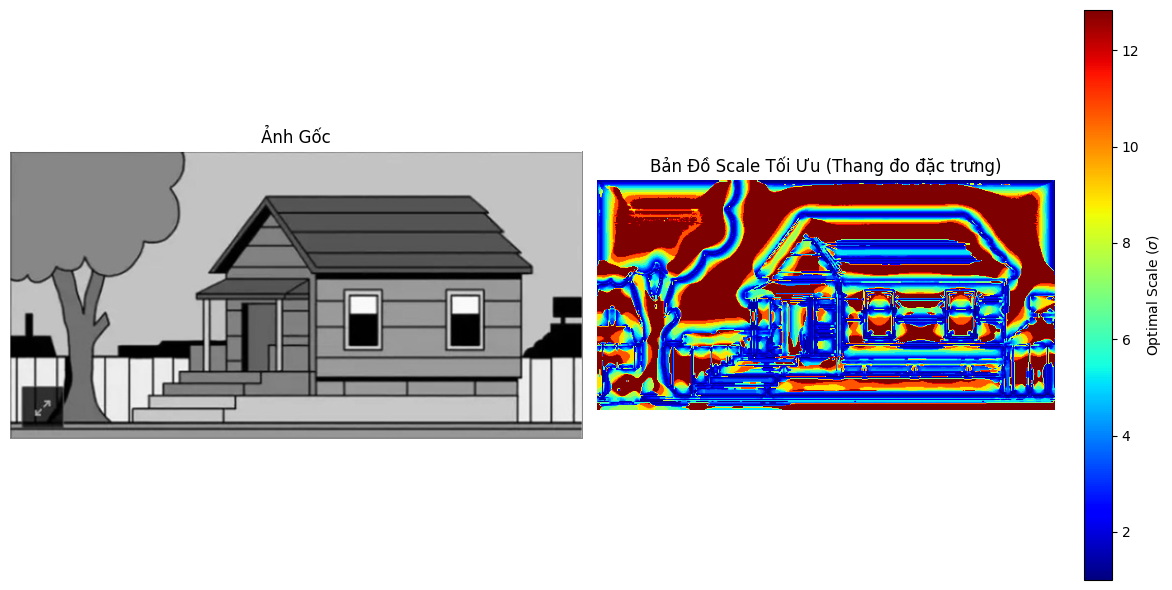

In [6]:
num_scales = 15
initial_sigma = 1.0
k = 1.2

# Đưa về [0, 1] để tính toán đạo hàm mượt mà hơn, tránh tràn số
img_f = gray.astype(np.float32) / 255.0
h, w = img_f.shape

# Khối lập phương 3D chứa phản ứng của hàm LoG tại mọi scale
scale_space = np.zeros((h, w, num_scales), dtype=np.float32)
sigmas = [initial_sigma * (k**i) for i in range(num_scales)]

# Xây dựng Scale-Space (Không gian tỷ lệ)
for i, sigma in enumerate(sigmas):
    # Làm mờ Gaussian (giả lập việc nhìn xa ra)
    # kernel=(0,0) để OpenCV tự tính size dựa trên sigma
    blurred = cv2.GaussianBlur(img_f, (0, 0), sigmaX=sigma, sigmaY=sigma)

    # Dùng Laplacian (đạo hàm bậc 2) để bắt cạnh/blob
    laplacian = cv2.Laplacian(blurred, cv2.CV_32F)

    # Scale Normalization
    # Dùng trị tuyệt đối vì Laplacian phản ứng âm với blob sáng trên nền tối
    normalized_laplacian = (sigma**2) * np.abs(laplacian)

    # Lưu vào không gian 3D
    scale_space[:, :, i] = normalized_laplacian

# Lựa Chọn Thang Đo Tự Động (Automatic Scale Selection)
# Lấy argmax theo trục Z (trục scale) để tìm sigma tốt nhất cho TỪNG pixel
best_scale_indices = np.argmax(scale_space, axis=2)

# Lấy ma trận chứa giá trị sigma tốt nhất (chỉ để visualize)
best_sigma_map = np.array(
    [sigmas[idx] for idx in best_scale_indices.flatten()]
).reshape(h, w)

# Hiển thị bằng màu "nhiệt độ" (Heatmap)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_f, cmap="gray")
plt.title("Ảnh Gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
# Những vùng màu đỏ/vàng trên heatmap là nơi vật thể cần scale (sigma) lớn
# Những vùng xanh đậm là chi tiết nhỏ (cần sigma nhỏ)
plt.imshow(best_sigma_map, cmap="jet")
plt.colorbar(label="Optimal Scale ($\sigma$)")
plt.title("Bản Đồ Scale Tối Ưu (Thang đo đặc trưng)")
plt.axis("off")

plt.tight_layout()
plt.show()

# Scale Invariant Detection

Đã bắt được 713 keypoints bất tử!


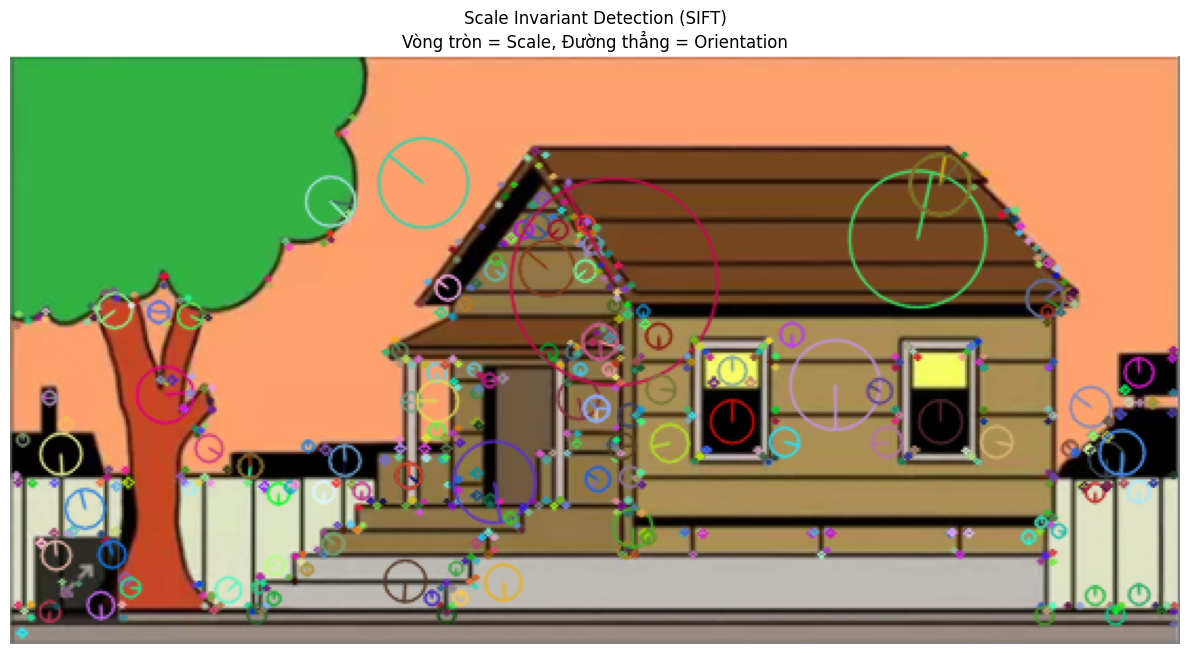

In [7]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
sift = cv2.SIFT_create()

# 3. Phát hiện Keypoint và tính toán Descriptor (Vector đặc trưng 128 chiều)
# Hàm này trả về 2 thứ:
# - keypoints: Danh sách các tọa độ, kích thước, và hướng.
# - descriptors: Ma trận chứa các vector đại diện cho từng điểm (dùng để match ảnh).
keypoints, descriptors = sift.detectAndCompute(gray, None)

print(f"Đã bắt được {len(keypoints)} keypoints bất tử!")

# Vẽ Keypoints lên ảnh
# Cờ DRAW_RICH_KEYPOINTS cực kỳ quan trọng:
# Nó sẽ vẽ một vòng tròn đại diện cho Scale (kích thước của chi tiết)
# Và một đường thẳng bên trong chỉ Hướng (Orientation) của góc cạnh đó.
img_with_keypoints = cv2.drawKeypoints(
    img_rgb,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    # color=(0, 255, 0)
)

plt.figure(figsize=(12, 8))
plt.imshow(img_with_keypoints)
plt.title(
    "Scale Invariant Detection (SIFT)\nVòng tròn = Scale, Đường thẳng = Orientation"
)
plt.axis("off")
plt.tight_layout()
plt.show()

# Scale-space blob detector

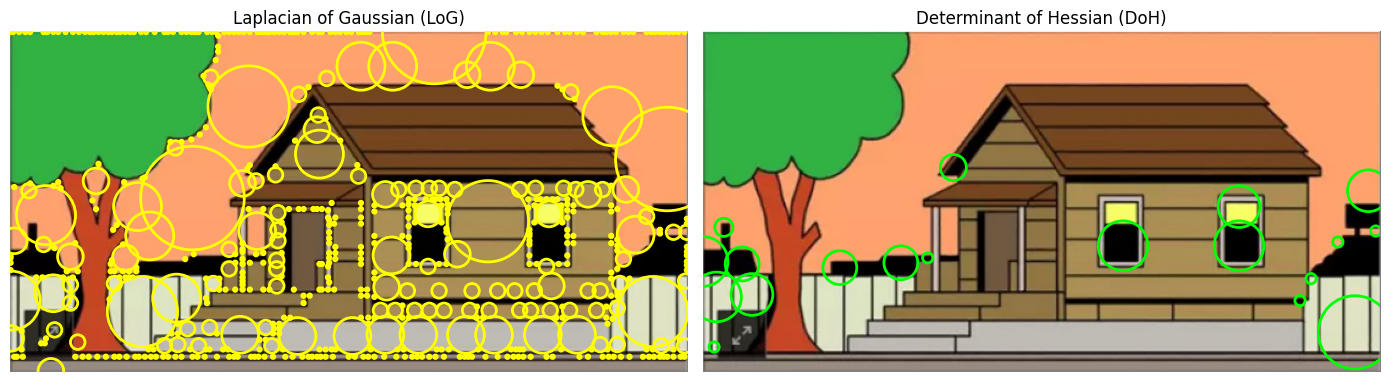

In [9]:
from skimage import color
from skimage.feature import blob_dog, blob_log, blob_doh
from math import sqrt

# Laplacian of Gaussian (LoG)
# min_sigma, max_sigma: Kích thước chùm radar (từ bé đến lớn)
# num_sigma: Số lượng lớp cắt trong Scale-space
# threshold: Độ nhạy của radar. Giảm xuống thì bắt được cả rác nhiễu.
blobs_log = blob_log(gray, max_sigma=30, num_sigma=10, threshold=0.1)

# Công thức tính bán kính (radius) chuẩn của LoG: r = sqrt(2) * sigma
blobs_log[:, 2] = blobs_log[:, 2] * sqrt(2)

# Determinant of Hessian (DoH)
# DoH đo tốc độ nhanh hơn ở các scale lớn!
blobs_doh = blob_doh(gray, max_sigma=30, threshold=0.01)


# Hàm hỗ trợ vẽ vòng tròn
def plot_blobs(ax, blobs, color_name, title):
    ax.set_title(title)
    ax.imshow(img_rgb)
    for blob in blobs:
        y, x, r = blob
        c = plt.Circle((x, y), r, color=color_name, linewidth=2, fill=False)
        ax.add_patch(c)
    ax.set_axis_off()


fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)
ax = axes.ravel()

plot_blobs(ax[0], blobs_log, "yellow", "Laplacian of Gaussian (LoG)")
plot_blobs(ax[1], blobs_doh, "lime", "Determinant of Hessian (DoH)")

plt.tight_layout()
plt.show()

# Thực hành với Bag-of-words detection

In [11]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


def build_visual_vocabulary(image_paths, k_words=50):
    """
    Khai thác đặc trưng từ danh sách ảnh và xây dựng Từ điển thị giác.
    k_words: Số lượng "từ vựng" (số chiều của vector Histogram đầu ra).
    """
    sift = cv2.SIFT_create()
    all_descriptors = []
    image_descriptors = []  # Lưu lại descriptor của từng ảnh để xài sau

    print(f"Bắt đầu xử lý {len(image_paths)} bức ảnh...")

    # 1. Thu thập mọi mảnh ghép (Descriptors)
    for path in image_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        keypoints, descriptors = sift.detectAndCompute(img, None)
        if descriptors is not None:
            all_descriptors.append(descriptors)
            image_descriptors.append(descriptors)
        else:
            image_descriptors.append(np.array([]))

    # Gộp tất cả descriptor của mọi ảnh thành một ma trận khổng lồ
    # Kích thước: (Tổng số keypoints, 128)
    massive_descriptor_pool = np.vstack(all_descriptors)
    print(
        f"Đã gom được tổng cộng {massive_descriptor_pool.shape[0]} vectors 128-chiều."
    )

    # 2. Huấn luyện "Từ điển" bằng K-Means
    print(f"Đang chạy K-Means để lấy ra {k_words} từ vựng...")
    kmeans = KMeans(n_clusters=k_words, random_state=42, n_init=10)
    kmeans.fit(massive_descriptor_pool)

    # Từ điển của chúng ta chính là tâm của các cụm!
    visual_dictionary = kmeans.cluster_centers_
    print("Đúc từ điển xong!")

    return kmeans, image_descriptors


def create_bow_histogram(kmeans_model, descriptors, k_words):
    """
    Chuyển đổi descriptor của một ảnh thành vector Histogram cố định.
    """
    histogram = np.zeros(k_words)
    if len(descriptors) > 0:
        # Dự đoán xem mỗi descriptor thuộc "từ vựng" (cụm) nào
        words = kmeans_model.predict(descriptors)

        # Đếm tần suất xuất hiện của mỗi từ vựng
        for word in words:
            histogram[word] += 1

        # L2 Normalization (Chuẩn hóa) để triệt tiêu sự chênh lệch do kích thước ảnh
        histogram = histogram / np.linalg.norm(histogram)

    return histogram


# Chạy thử
dummy_paths = ["cat1.jpg", "cat2.jpg", "dog1.jpg", "dog2.jpg"]
kmeans_model, img_descs = build_visual_vocabulary(dummy_paths, k_words=50)

# Chuyển ảnh đầu tiên thành vector đặc trưng BoVW
hist_vector = create_bow_histogram(kmeans_model, img_descs[0], k_words=50)
print("Vector BoVW của ảnh 1:", hist_vector)

Bắt đầu xử lý 4 bức ảnh...
Đã gom được tổng cộng 95311 vectors 128-chiều.
Đang chạy K-Means để lấy ra 50 từ vựng...
Đúc từ điển xong!
Vector BoVW của ảnh 1: [0.19644555 0.12044589 0.10924951 0.14402614 0.10704416 0.08244606
 0.14131186 0.20357051 0.09805313 0.07769608 0.11942803 0.16692782
 0.19288306 0.08380319 0.22392756 0.28482908 0.08736568 0.19644555
 0.16370462 0.15132075 0.10314239 0.12316016 0.14691005 0.15624037
 0.14249936 0.18219561 0.09924063 0.0632765  0.08566926 0.13639224
 0.09262458 0.16336534 0.11281199 0.08431212 0.13893688 0.09092816
 0.08125856 0.09177637 0.1212941  0.12248159 0.15098146 0.08193713
 0.28940941 0.06683899 0.07396395 0.1374101  0.1737135  0.11332092
 0.15166003 0.06887469]


# Ghép ảnh Image Panoramas 

Tìm thấy 1378 điểm nối hoàn hảo!


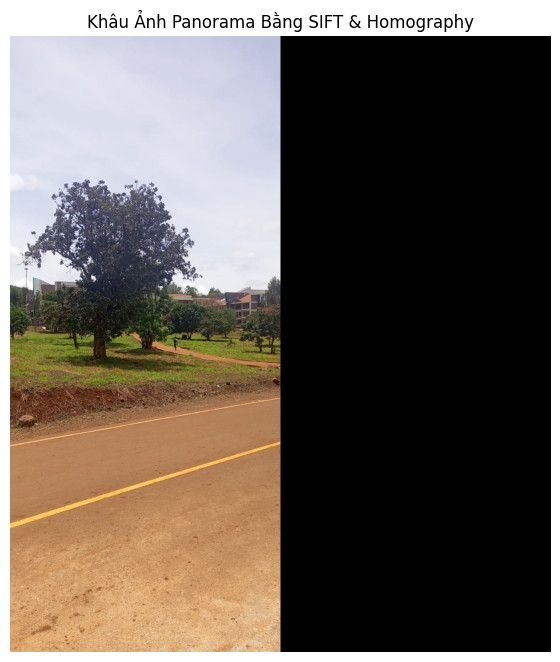

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def build_panorama(img_left_path, img_right_path):
    # 1. Đọc ảnh
    img_left = cv2.imread(img_left_path)
    img_right = cv2.imread(img_right_path)

    if img_left is None or img_right is None:
        print("Lỗi: Không load được ảnh.")
        return

    gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
    gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

    # 2. Triệu hồi SIFT để tìm Keypoint và Descriptor
    sift = cv2.SIFT_create()
    kp_left, des_left = sift.detectAndCompute(gray_left, None)
    kp_right, des_right = sift.detectAndCompute(gray_right, None)

    # 3. Nối điểm bằng FLANN (Fast Library for Approximate Nearest Neighbors)
    # Nhanh và xịn hơn Brute-Force Matcher rất nhiều
    index_params = dict(algorithm=1, trees=5)  # 1 = FLANN_INDEX_KDTREE
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    # Tìm 2 điểm gần nhất (k=2) cho mỗi descriptor
    matches = flann.knnMatch(des_left, des_right, k=2)

    # 4. Tinh lọc điểm nối bằng Ratio Test của tác giả David Lowe (Cha đẻ thuật toán SIFT)
    # Chỉ giữ lại những điểm khớp nhau thực sự rõ ràng
    good_matches = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)

    print(f"Tìm thấy {len(good_matches)} điểm nối hoàn hảo!")

    # Cần ít nhất 4 điểm để tính ma trận Homography, nhưng lấy 10 cho chắc
    MIN_MATCH_COUNT = 10
    if len(good_matches) > MIN_MATCH_COUNT:
        # 5. Tách tọa độ (x,y) của các điểm nối tốt
        src_pts = np.float32([kp_left[m.queryIdx].pt for m in good_matches]).reshape(
            -1, 1, 2
        )
        dst_pts = np.float32([kp_right[m.trainIdx].pt for m in good_matches]).reshape(
            -1, 1, 2
        )

        # 6. Tìm ma trận Homography (M) bằng RANSAC
        # M là ma trận 3x3 chứa công thức bẻ cong hệ tọa độ ảnh trái sang ảnh phải
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

        # 7. Phép thuật biến hình (Warp Perspective)
        h_right, w_right = gray_right.shape
        h_left, w_left = gray_left.shape

        # Bẻ cong ảnh trái và trải nó lên một khung canvas rỗng (chiều rộng = tổng 2 ảnh)
        canvas_width = w_left + w_right
        canvas_height = max(h_left, h_right)

        panorama = cv2.warpPerspective(img_left, M, (canvas_width, canvas_height))

        # 8. Chèn ảnh phải vào canvas
        # Vì ảnh trái đã bị bẻ cong sang hệ tọa độ của ảnh phải,
        # ta chỉ cần dán ảnh phải đè lên gốc tọa độ (0,0) là chúng tự khớp nhau.
        panorama[0:h_right, 0:w_right] = img_right

        # 9. Lên hình
        plt.figure(figsize=(16, 8))
        plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
        plt.title("Khâu Ảnh Panorama Bằng SIFT & Homography")
        plt.axis("off")
        plt.show()

    else:
        print(
            f"Thất bại: Không có đủ điểm chung để ghép. ({len(good_matches)}/{MIN_MATCH_COUNT})"
        )


build_panorama("aImage/image 5.jpg", "aImage/image 7.jpg")

Khởi động Mosaicing...
Đã nhét 9 bức ảnh vào lò phản ứng.
Bắt đầu trích xuất đặc trưng, giải ma trận và trộn màu. Đợi xíu nhé...
Mosaicing thành công rực rỡ.


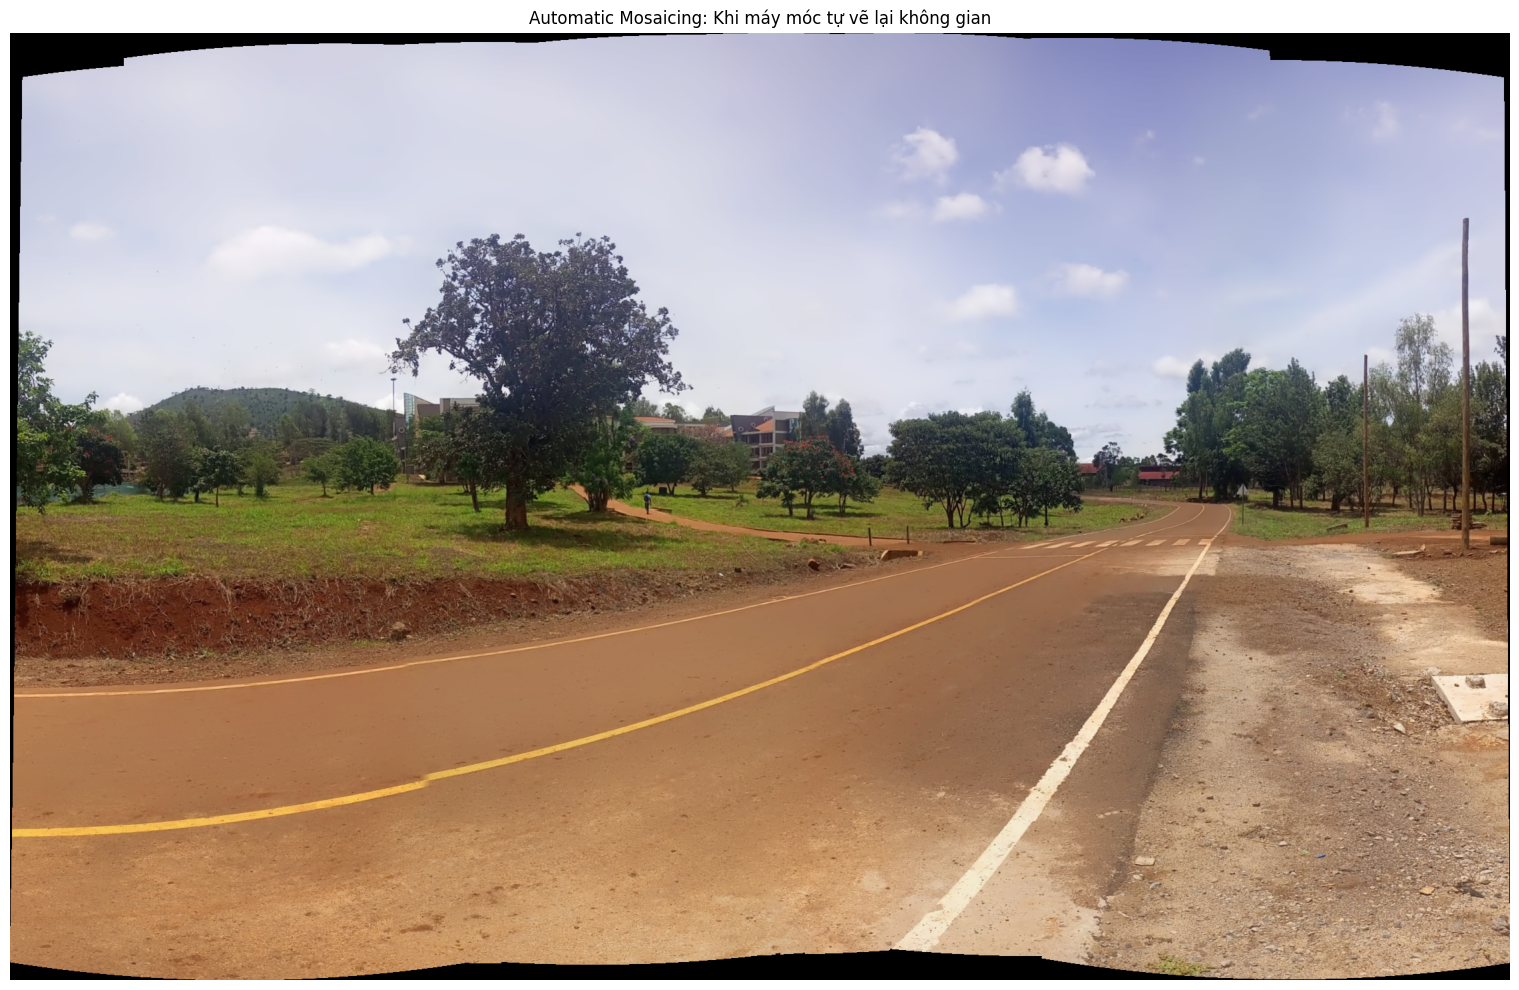

In [ ]:
import cv2
import glob
import os
import matplotlib.pyplot as plt


def auto_mosaic_wizard(image_folder):
    print("Khởi động Mosaicing...")

    # 1. Hút toàn bộ ảnh từ thư mục (dùng glob cho lẹ)
    # Hỗ trợ cả đường dẫn kiểu Windows (\\) lẫn Linux (/)
    image_paths = glob.glob(os.path.join(image_folder, "*.jpg"))

    if len(image_paths) < 2:
        print("Lỗi hệ thống: Cần ít nhất 2 bức ảnh để chạy")
        return

    images = []
    for path in image_paths:
        img = cv2.imread(path)
        if img is not None:
            images.append(img)

    print(f"Đã nhét {len(images)} bức ảnh vào để xử lý")

    # 2. Stitcher
    # cv2.Stitcher_PANORAMA: Dùng cho ảnh chụp xoay quanh 1 trục (phong cảnh)
    # cv2.Stitcher_SCANS: Dùng cho ảnh scan tài liệu hoặc chụp phẳng từ trên xuống
    stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)

    # 3. Kích hoạt (Quá trình này ngốn khá nhiều CPU)
    print("Bắt đầu trích xuất đặc trưng, giải ma trận và trộn màu. Đợi xíu nhé...")
    status, mosaic = stitcher.stitch(images)

    # 4. Kiểm tra thành quả
    if status == cv2.Stitcher_OK:
        print("Mosaicing thành công rực rỡ.")

        # Chuyển BGR sang RGB để vẽ bằng Matplotlib
        mosaic_rgb = cv2.cvtColor(mosaic, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(20, 10))
        plt.imshow(mosaic_rgb)
        plt.title("Automatic Mosaicing: Khi máy móc tự vẽ lại không gian")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        # Bạn có thể lưu lại nếu thích
        # cv2.imwrite('mega_panorama.jpg', mosaic)

    else:
        # Giải mã lỗi nếu cỗ máy vấp ngã
        errors = {
            cv2.Stitcher_ERR_NEED_MORE_IMGS: "Thiếu ảnh hoặc ảnh không có điểm chung.",
            cv2.Stitcher_ERR_HOMOGRAPHY_EST_FAIL: "Lỗi nội suy RANSAC, không tìm được ma trận không gian.",
            cv2.Stitcher_ERR_CAMERA_PARAMS_ADJUST_FAIL: "Thất bại khi cố đoán thông số Camera.",
        }
        print(f"Mã lỗi: {errors.get(status, 'Lỗi')}")


# Chạy thử thôi! Chỉ cần vứt đường dẫn thư mục chứa ảnh vào đây
auto_mosaic_wizard("aImage")